# CHES-related analysis

This notebook is dedicated to the processing and analysis of trends of the CHES variables. 
Focus identities and related variables: 
- LRGEN and LRECON: general left-right positioning, economic left-right positioning
- Families: The ideologies that the parties subscribe to
- GAL-TAN: Positioning of political parties according to the libertarian - traditional axis. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly as px

In [2]:
df = pd.read_csv("../Datasets/CHES-SI.tsv", sep="\t", encoding="utf-8")
cols = ["parlamint", "party_id", "party", "year", "lrgen", "lrecon", "galtan", "family"]
df = df[cols]
print(df.shape)
df.head(10)

(49, 8)


,parlamint,party_id,party,year,lrgen,lrecon,galtan,family
0,-,2909,AS,2006,4.6,3.8,2.6,7
1,-,2904,SLS-SMS,2010,6.8,5.3,7.8,4
2,DL,-,-,-,-,-,-,-
3,DLGV,-,-,-,-,-,-,-
4,DeSUS,2906,DeSUS,2002,3.4,3.4,5.8,9
5,DeSUS,2906,DeSUS,2006,3.2,2.6,4.5,9
6,DeSUS,2906,DeSUS,2010,4.2,3.3,5.2,9
7,DeSUS,2906,DeSUS,2014,4.2,4.0,5.3,9
8,DeSUS,2906,DeSUS,2019,3.8,3.3,5.1,9
9,GAS,-,-,-,-,-,-,-


In [3]:
#Parties in ParlaMint, but not in CHES: DL, DLGV, GAS, Konkretno, Lipa, NP, NeP
df = df[df["parlamint"]!="-"]
df = df[df["lrgen"] != "-"]

df

,parlamint,party_id,party,year,lrgen,lrecon,galtan,family
4,DeSUS,2906,DeSUS,2002,3.4,3.4,5.8,9
5,DeSUS,2906,DeSUS,2006,3.2,2.6,4.5,9
6,DeSUS,2906,DeSUS,2010,4.2,3.3,5.2,9
7,DeSUS,2906,DeSUS,2014,4.2,4.0,5.3,9
8,DeSUS,2906,DeSUS,2019,3.8,3.3,5.1,9
11,LDS,2901,LDS,2002,4.2,6.2,3,3
12,LDS,2901,LDS,2006,3.4,3.8,2.8,3
13,LDS,2901,LDS,2010,4.8,5.8,1.6,3
14,LMŠ,2915,LMS,2019,4.4,4.6,4.6,3
15,Levica,2912,Levica,2019,0.7,0.7,1,5


In [4]:
mapping={
    "1":"Radical Right", 
    "2":"Conservatives",
    "3":"Liberal", 
    "4":"Christian-Democratic",
    "5":"Socialist", 
    "6":"Radical Left", 
    "7":"Green", 
    "8":"Regionalist", 
    "9":"No family", 
    "10":"Confessional", 
    "11":"Agrarian/Center"
}

df["family"] = df["family"].map(mapping).fillna(df["family"])
df.head()

,parlamint,party_id,party,year,lrgen,lrecon,galtan,family
4,DeSUS,2906,DeSUS,2002,3.4,3.4,5.8,No family
5,DeSUS,2906,DeSUS,2006,3.2,2.6,4.5,No family
6,DeSUS,2906,DeSUS,2010,4.2,3.3,5.2,No family
7,DeSUS,2906,DeSUS,2014,4.2,4.0,5.3,No family
8,DeSUS,2906,DeSUS,2019,3.8,3.3,5.1,No family


# Distributions

### Family
(CHES Codebook definition) "FAMILY= classification was initially based on Hix and Lord (1997), except that we place confessional and agrarian parties in separate categories. Family association for parties in Central/Eastern Europe was based initially on Derksen classification (now incorporated in Wikipedia), triangulated by a) membership or aﬃliation with international and EU party associations, and b) self-identification. We update family codings based on ideological shifts or organizational changes."

In [5]:
#Check families
family_cols = ["parlamint", "party", "year", "family"]
family = df[family_cols]

family = family.sort_values(by=["party", "year"])
family["family_change"] = family.groupby("party")["family"].transform(lambda x: x != x.iloc[0])
changes = family[family["family_change"] != False]

print("Parties with family changes:")
print(changes)
#No changes in the Family during the years

family


Parties with family changes:
Empty DataFrame
Columns: [parlamint, party, year, family, family_change]
Index: []


,parlamint,party,year,family,family_change
26,SAB + ZaSLD,AB,2019,No family,False
4,DeSUS,DeSUS,2002,No family,False
5,DeSUS,DeSUS,2006,No family,False
6,DeSUS,DeSUS,2010,No family,False
7,DeSUS,DeSUS,2014,No family,False
8,DeSUS,DeSUS,2019,No family,False
11,LDS,LDS,2002,Liberal,False
12,LDS,LDS,2006,Liberal,False
13,LDS,LDS,2010,Liberal,False
14,LMŠ,LMS,2019,Liberal,False


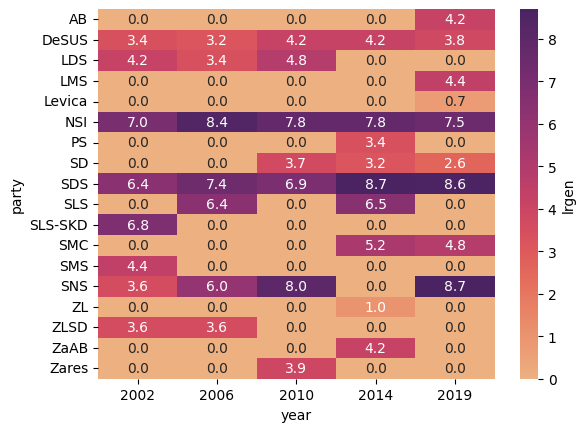

In [6]:
lrgen_pivot = df.pivot(index="party", columns="year", values="lrgen").fillna(0)
lrgen_pivot = lrgen_pivot.astype(float)

sns.heatmap(
    lrgen_pivot, 
    annot=True, fmt=".1f", cmap="flare", cbar_kws={'label': 'lrgen'}
)
plt.show()

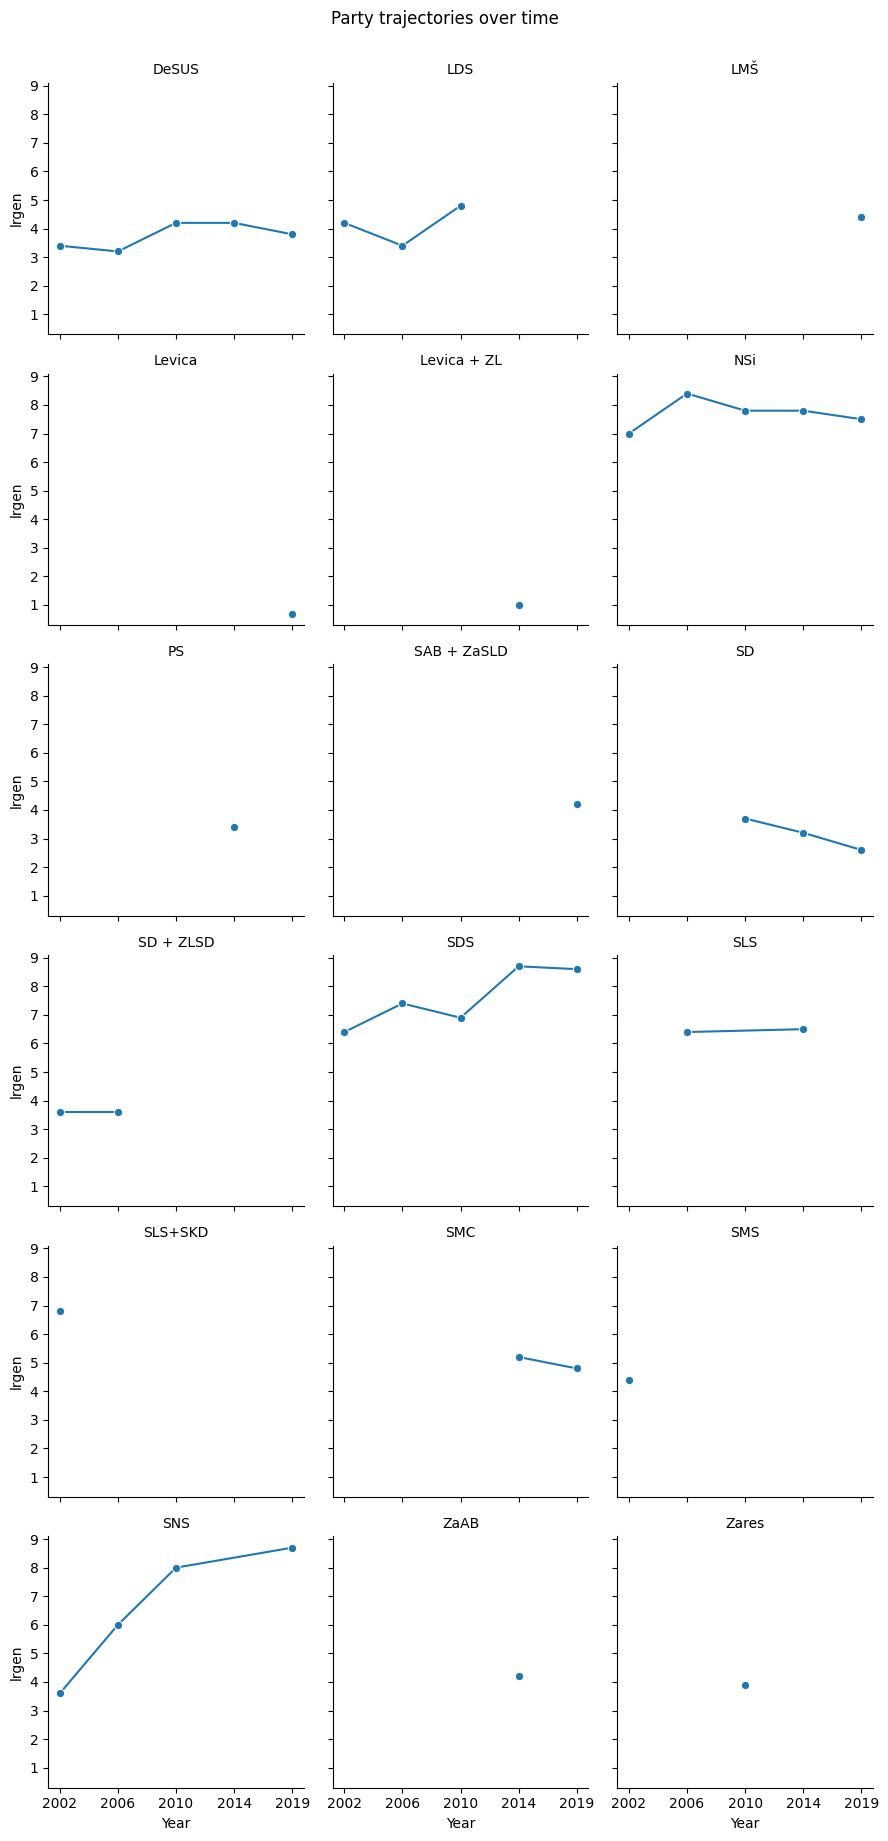

In [9]:
import numpy as np
df["lrgen"] = pd.to_numeric(df["lrgen"])
g = sns.FacetGrid(df, col="parlamint", col_wrap=3, height=3, sharey=True)
g.map_dataframe(sns.lineplot, x="year", y="lrgen", marker="o")

g.set_axis_labels("Year", "lrgen")
g.set_titles("{col_name}")
g.fig.suptitle("Party trajectories over time", y=1.02)

plt.show()